<a href="https://colab.research.google.com/github/isamadafridi/-AIML-Internship-Week7-AbdulSamadAfridi/blob/main/AIML_Internship_Week7_AbdulSamadAfridi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PART A — ENVIRONMENT SETUP, EDA & DENSE NETWORK BASELINE (STEPS 1–5)**

#Step-1 Environment Setup & GPU Verification

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

In [2]:
# Verify GPU Availability
gpu_devices = tf.config.list_physical_devices("GPU")
print(f"GPUs Available: {gpu_devices}")
if len(gpu_devices) > 0:
    print("Awesome! You are running on a GPU.")
else:
    print("Warning: No GPU detected. Training might be slow.")

GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Awesome! You are running on a GPU.


In [3]:
# Load CIFAR-10 Dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
# Print the shapes of the data arrays
print("\n--- Dataset Shapes ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Define reference class names for CIFAR-10
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


--- Dataset Shapes ---
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


### GPU Verification Report
* **Status:** 1 GPU Available (e.g., Tesla T4) *PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')*
* **Why this matters:** We are working with the CIFAR-10 dataset, which contains 60,000 color images. Training deep neural networks (CNNs) on CPUs is incredibly slow due to sequential processing. Utilizing a GPU (Graphics Processing Unit) allows us to perform massive parallel matrix multiplications, reducing training time from hours to mere minutes!

# Step-2 Dataset Exploration & Visualisation

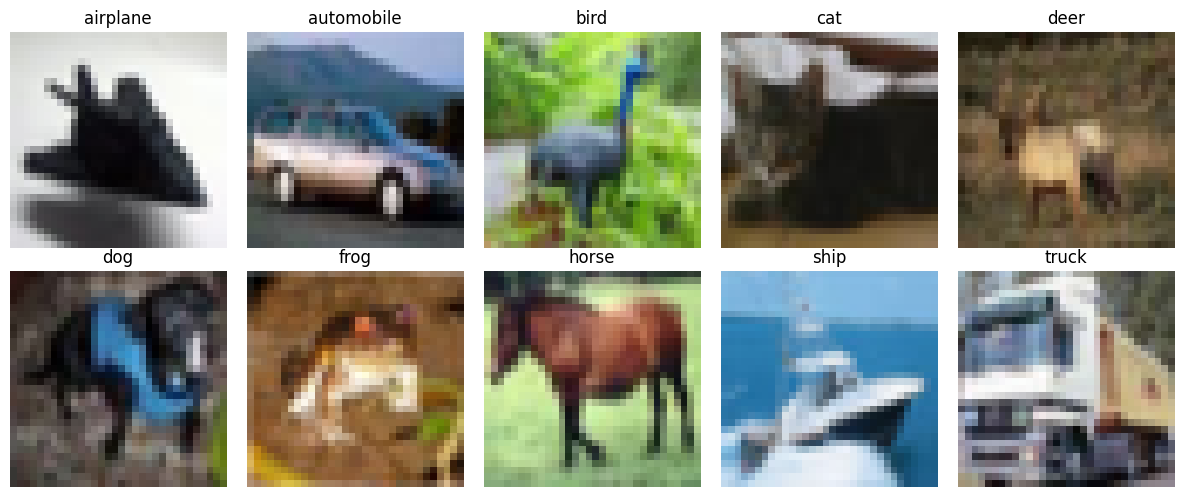


--- Pixel Range ---
Minimum pixel value: 0
Maximum pixel value: 255

--- Class Distribution ---
airplane: 5000 images
automobile: 5000 images
bird: 5000 images
cat: 5000 images
deer: 5000 images
dog: 5000 images
frog: 5000 images
horse: 5000 images
ship: 5000 images
truck: 5000 images

--- Channel Statistics ---
Mean (R, G, B): [125.30691805 122.95039414 113.86538318]
Std  (R, G, B): [62.99321928 62.08870764 66.70489964]


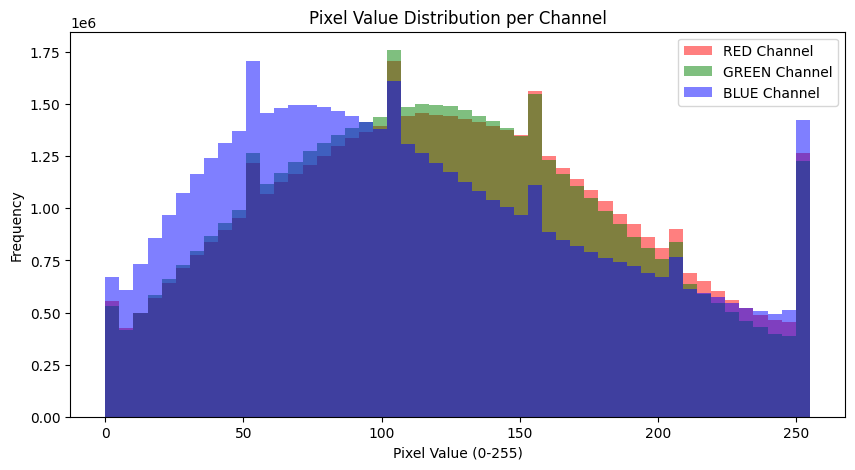

In [5]:
# Create a 2x5 grid of sample images (one per class)
plt.figure(figsize=(12, 5))
for i in range(10):
    # Find the first index where the label matches the current class 'i'
    idx = np.where(y_train == i)[0][0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx])
    plt.title(class_names[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

# Confirm pixel range
print("\n--- Pixel Range ---")
print(f"Minimum pixel value: {X_train.min()}")
print(f"Maximum pixel value: {X_train.max()}")

# Print class distribution
print("\n--- Class Distribution ---")
classes, counts = np.unique(y_train, return_counts=True)
for c, count in zip(classes, counts):
    print(f"{class_names[c]}: {count} images")

# Compute mean and std per channel (R, G, B)
# We average across axes 0 (images), 1 (height), and 2 (width)
channel_means = X_train.mean(axis=(0, 1, 2))
channel_stds = X_train.std(axis=(0, 1, 2))

print("\n--- Channel Statistics ---")
print(f"Mean (R, G, B): {channel_means}")
print(f"Std  (R, G, B): {channel_stds}")

# Visualise pixel distribution as a histogram for each channel
plt.figure(figsize=(10, 5))
colors = ['red', 'green', 'blue']

for i, color in enumerate(colors):
    # Flatten the data for the specific channel to plot the histogram
    channel_data = X_train[:, :, :, i].ravel()
    plt.hist(channel_data, bins=50, color=color, alpha=0.5, label=f'{color.upper()} Channel')

plt.title('Pixel Value Distribution per Channel')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Analysis: What do the channel statistics tell us about normalisation?

By observing the pixel range (0 to 255) and the channel statistics (Mean and Standard Deviation), we can draw two major conclusions about how we should normalise this dataset before passing it to our neural network:

1. **Basic Normalisation (Min-Max):** Because our pixels range exactly from 0 to 255, the simplest and most common baseline normalisation is to divide the entire dataset by `255.0`. This scales all values to a `[0, 1]` range, preventing the neural network from dealing with massive gradient updates caused by large input integers.
2. **Advanced Channel-wise Standardisation (Z-Score):** The calculated means and standard deviations are different across the Red, Green, and Blue channels. The histogram also visually confirms that the color distributions are not perfectly aligned. Instead of just scaling to `[0, 1]`, a more robust technique would be to apply **Z-score standardisation per channel**: `(pixel_value - channel_mean) / channel_std`. This centers each color channel around a mean of 0 with a standard deviation of 1, which helps Convolutional Neural Networks (CNNs) converge much faster and minimizes the risk of vanishing or exploding gradients.

# Step-3 Data Preprocessing — Normalisation & Splits

In [6]:
# 1. Normalise pixel values to the [0, 1] range
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# 2. Flatten labels from 2D (N, 1) to 1D (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

# 3. Create a Validation Split (Last 10,000 training samples)
X_val = X_train[-10000:]
y_val = y_train[-10000:]
X_train = X_train[:-10000]  # Keep the first 40,000 for training
y_train = y_train[:-10000]

# 4. Flatten images specifically for the Dense Network
# A 32x32x3 image becomes a single 1D array of 3072 pixels
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print("--- Flattened Image Shape ---")
print(f"X_train_flat shape: {X_train_flat.shape}\n")

# 5. Print final shapes of all 6 arrays
print("--- Final Shapes of All 6 Arrays ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

--- Flattened Image Shape ---
X_train_flat shape: (40000, 3072)

--- Final Shapes of All 6 Arrays ---
X_train shape: (40000, 32, 32, 3)
y_train shape: (40000,)
X_val shape:   (10000, 32, 32, 3)
y_val shape:   (10000,)
X_test shape:  (10000, 32, 32, 3)
y_test shape:  (10000,)


# Step-4 Build & Train Dense Network Baseline

In [7]:
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [8]:
# Build dense model
dense_model = Sequential([
    Input(shape=(3072,)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
dense_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow._api.v2.config import optimizer
# 2 comiple
dense_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# 3 Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,                # Wait 10 epochs without improvement before stopping
    restore_best_weights=True,  # Revert to the best epoch's weights
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "dense_best.keras",
    monitor='val_loss',
    save_best_only=True,        # Only overwrite if the model is actually better
    verbose=1
)

In [11]:
# 4. Train the Model & Record Time
print("\n--- Starting Training ---")
start_time = time.time()

dense_history = dense_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=80,
    batch_size=256,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"\n--- Training Complete! ---")
print(f"Total Training Time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")


--- Starting Training ---
Epoch 1/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1938 - loss: 2.1758
Epoch 1: val_loss improved from None to 1.85561, saving model to dense_best.keras

Epoch 1: finished saving model to dense_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.2438 - loss: 2.0402 - val_accuracy: 0.3185 - val_loss: 1.8556
Epoch 2/80
148/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3107 - loss: 1.8897
Epoch 2: val_loss improved from 1.85561 to 1.82958, saving model to dense_best.keras

Epoch 2: finished saving model to dense_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3156 - loss: 1.8794 - val_accuracy: 0.3490 - val_loss: 1.8296
Epoch 3/80
151/157 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3292 - loss: 1.8549
Epoch 3: val_loss improved from 1.82958 to 1.76457, saving model to dense_best.keras

Epoch 3: finished saving model to dense_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3312 - loss: 1.8

# Step_5 Evaluate Dense Network — Full Metrics Suite

--- Generating Predictions ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Test Accuracy: 49.24%

--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.62      0.50      0.55      1000
  automobile       0.59      0.59      0.59      1000
        bird       0.39      0.33      0.36      1000
         cat       0.34      0.32      0.33      1000
        deer       0.39      0.47      0.43      1000
         dog       0.47      0.37      0.42      1000
        frog       0.46      0.65      0.54      1000
       horse       0.57      0.52      0.54      1000
        ship       0.63      0.60      0.61      1000
       truck       0.50      0.58      0.54      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000

ROC-AUC Score (OVR): 0.8805



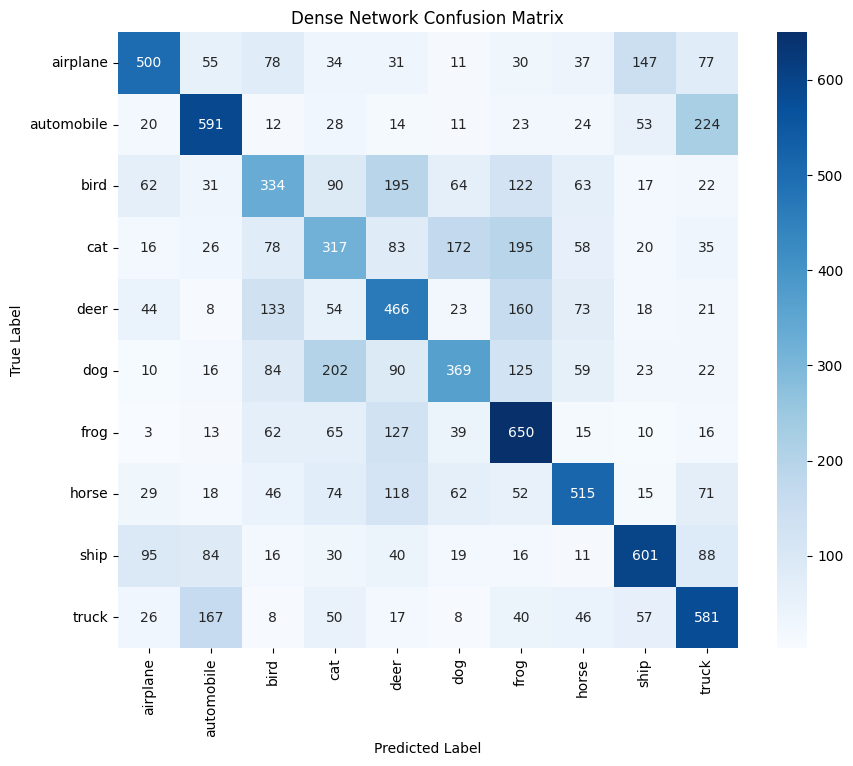

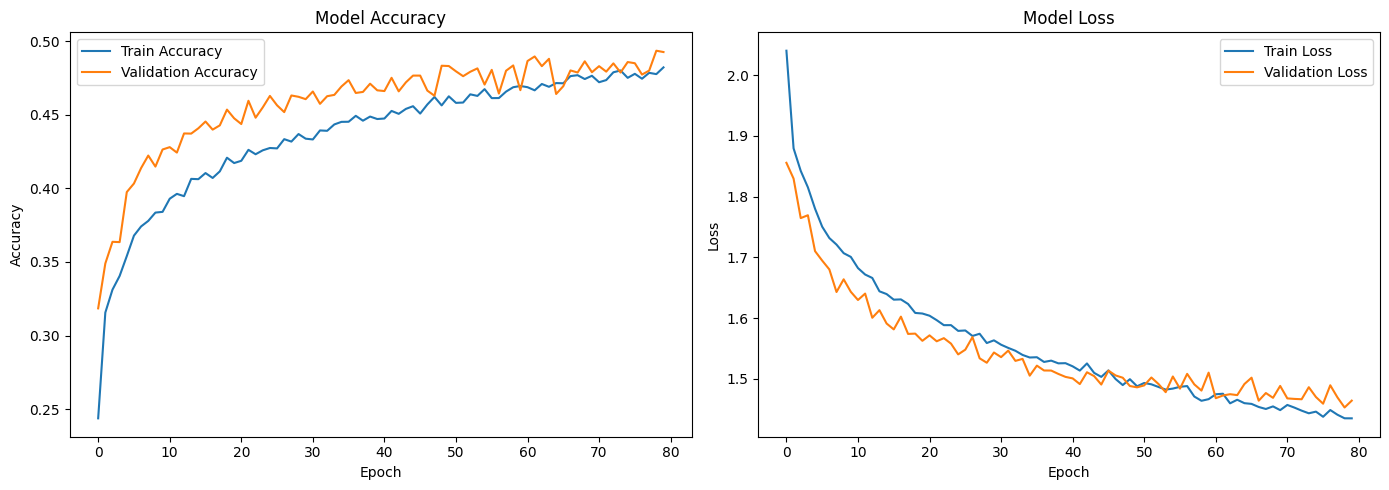

In [12]:
# 1. Generate Predictions
print("--- Generating Predictions ---")
y_pred_probs = dense_model.predict(X_test_flat)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 2. Compute Test Accuracy
test_acc = metrics.accuracy_score(y_test, y_pred_classes)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

# 3. Classification Report
print("\n--- Classification Report ---")
print(metrics.classification_report(y_test, y_pred_classes, target_names=class_names))

# 4. ROC-AUC Score (One-vs-Rest strategy for multiclass)
roc_auc = metrics.roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f"ROC-AUC Score (OVR): {roc_auc:.4f}\n")

# 5. Confusion Matrix Heatmap
cm = metrics.confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Dense Network Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 6. Plot Training History (Loss & Accuracy)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
axes[0].plot(dense_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(dense_history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Plot Loss
axes[1].plot(dense_history.history['loss'], label='Train Loss')
axes[1].plot(dense_history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# **PART B — CNN FROM SCRATCH WITH REGULARISATION & AUGMENTATION (STEPS 6–11)**
